# IEMOCAP Audio-Only Pipeline

This notebook adapts the existing audio-only RAVDESS/MELD pipeline to `AbstractTTS/IEMOCAP`.

Key dataset-specific choices:
- use the Hugging Face IEMOCAP dataset directly
- hold out one session for testing to reduce speaker/session leakage
- drop `other` and labels with too few examples by default

## Imports

In [6]:
import ctypes
import os
import warnings

prefix = os.environ.get("CONDA_PREFIX")
if prefix:
    ctypes.CDLL(f"{prefix}/lib/libgcc_s.so.1", mode=ctypes.RTLD_GLOBAL)
    ctypes.CDLL(f"{prefix}/lib/libstdc++.so.6", mode=ctypes.RTLD_GLOBAL)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix
from transformers import Wav2Vec2Model, Wav2Vec2Processor

from iemocap_pipeline_utils import (
    EmotionClassifier,
    build_iemocap_metadata,
    build_label_maps,
    compute_class_weights,
    create_dataloaders,
    encode_labels,
    extract_wave2vec_features_from_rows,
    filter_iemocap_metadata,
    load_iemocap_train_split,
    scale_train_test,
    session_holdout_split,
    train_model,
    evaluate_model,
)

warnings.filterwarnings("ignore")
np.random.seed(42)
torch.manual_seed(42)

## Configuration

In [7]:
DATASET_ID = "AbstractTTS/IEMOCAP"
LABEL_COLUMN = "major_emotion"
DROP_LABELS = {"other"}
MIN_SAMPLES_PER_CLASS = 30
TEST_SESSIONS = ("Ses05",)
MAX_SAMPLES = None  # Set an int for quick smoke tests.

WAVE2VEC_MODEL_NAME = "facebook/wav2vec2-base-960h"
BATCH_SIZE = 32
NUM_EPOCHS = 30
LEARNING_RATE = 1e-3
DROPOUT = 0.5

CACHE_DIR = "IEMOCAP_cache"
FEATURE_CACHE_PATH = os.path.join(CACHE_DIR, "audio_wave2vec_features.npz")
CHECKPOINT_PATH = os.path.join("models", "IEMOCAP_audio_only.pth")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Load And Filter IEMOCAP

In [8]:
iemocap_dataset = load_iemocap_train_split(DATASET_ID)
metadata = build_iemocap_metadata(iemocap_dataset)
filtered_metadata, label_counts = filter_iemocap_metadata(
    metadata,
    label_column=LABEL_COLUMN,
    drop_labels=DROP_LABELS,
    min_samples_per_class=MIN_SAMPLES_PER_CLASS,
    max_samples=MAX_SAMPLES,
)

print(f"Original samples: {len(metadata)}")
print(f"Filtered samples: {len(filtered_metadata)}")
print(f"Labels kept: {label_counts.index.tolist()}")
label_counts

Original samples: 10039
Filtered samples: 10011
Labels kept: ['frustrated', 'excited', 'neutral', 'angry', 'sad', 'happy', 'surprise', 'fear']


major_emotion
frustrated    2917
excited       1976
neutral       1726
angry         1269
sad           1250
happy          656
surprise       110
fear           107
Name: count, dtype: int64

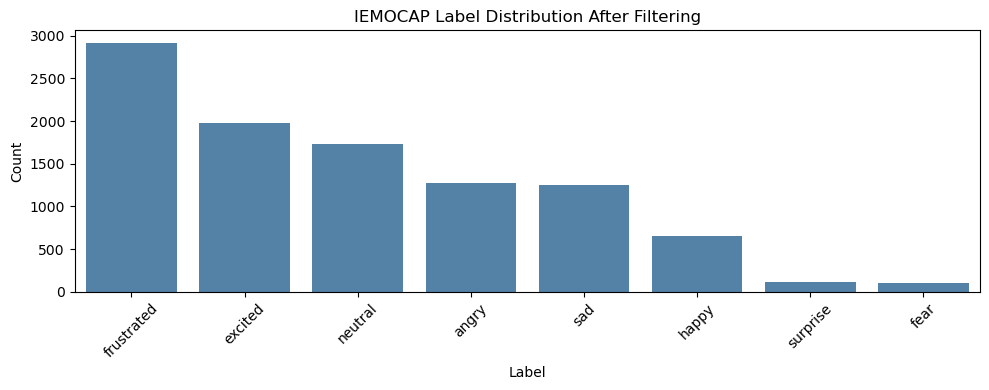

major_emotion,angry,excited,fear,frustrated,happy,neutral,sad,surprise
session_id,,,,,,,,
Ses01,270,300,20,427,146,392,229,27
Ses02,151,383,18,528,135,362,212,17
Ses03,286,352,16,631,154,327,339,28
Ses04,365,482,23,720,67,259,159,19
Ses05,197,459,30,611,154,386,311,19


In [9]:
plt.figure(figsize=(10, 4))
sns.barplot(x=label_counts.index, y=label_counts.values, color="steelblue")
plt.title("IEMOCAP Label Distribution After Filtering")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

pd.crosstab(filtered_metadata["session_id"], filtered_metadata[LABEL_COLUMN])

## Extract Wave2Vec2 Features

In [10]:
print(f"Loading Wave2Vec2 model: {WAVE2VEC_MODEL_NAME}")
processor = Wav2Vec2Processor.from_pretrained(WAVE2VEC_MODEL_NAME)
wave2vec_model = Wav2Vec2Model.from_pretrained(WAVE2VEC_MODEL_NAME, weights_only=False).to(device)
wave2vec_model.eval()

Loading Wave2Vec2 model: facebook/wav2vec2-base-960h


Loading weights:   0%|          | 0/210 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base-960h
Key               | Status     | 
------------------+------------+-
lm_head.bias      | UNEXPECTED | 
lm_head.weight    | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Wav2Vec2Model(
  (feature_extractor): Wav2Vec2FeatureEncoder(
    (conv_layers): ModuleList(
      (0): Wav2Vec2GroupNormConvLayer(
        (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
        (activation): GELUActivation()
        (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
      )
      (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
      (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
    )
  )
  (feature_projection): Wav2Vec2FeatureProjection(
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (projection): Linear(in_features=512, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): Wav2Vec2Encoder(
    (pos_conv_embed): Wav2Vec2PositionalConvEmbedding(
  

In [11]:
X = extract_wave2vec_features_from_rows(
    iemocap_dataset,
    filtered_metadata["row_idx"].to_numpy(),
    processor,
    wave2vec_model,
    device,
    cache_path=FEATURE_CACHE_PATH,
)
X.shape

Extracting audio features: 100%|██████████| 10011/10011 [01:40<00:00, 99.68it/s] 


Saved audio features to IEMOCAP_cache/audio_wave2vec_features.npz


(10011, 3072)

## Prepare Session Holdout Split

In [12]:
label_names, label_to_idx, idx_to_label = build_label_maps(filtered_metadata[LABEL_COLUMN])
y = encode_labels(filtered_metadata[LABEL_COLUMN], label_to_idx)

train_mask, test_mask = session_holdout_split(filtered_metadata, test_sessions=TEST_SESSIONS)

train_metadata = filtered_metadata.loc[train_mask].reset_index(drop=True)
test_metadata = filtered_metadata.loc[test_mask].reset_index(drop=True)

X_train_raw = X[train_mask]
X_test_raw = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

X_train, X_test, scaler = scale_train_test(X_train_raw, X_test_raw)
train_loader, test_loader = create_dataloaders(X_train, y_train, X_test, y_test, batch_size=BATCH_SIZE)
class_weights, class_counts = compute_class_weights(y_train, num_classes=len(label_names))

print(f"Train sessions: {sorted(train_metadata['session_id'].unique())}")
print(f"Test sessions: {sorted(test_metadata['session_id'].unique())}")
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
pd.Series(class_counts, index=label_names, name="train_count")

Train sessions: ['Ses01', 'Ses02', 'Ses03', 'Ses04']
Test sessions: ['Ses05']
Train shape: (7844, 3072)
Test shape: (2167, 3072)


angry         1072
excited       1517
fear            77
frustrated    2306
happy          502
neutral       1340
sad            939
surprise        91
Name: train_count, dtype: int64

## Train Classifier

In [13]:
model = EmotionClassifier(
    input_size=X_train.shape[1],
    num_emotions=len(label_names),
    dropout_rate=DROPOUT,
).to(device)

history = train_model(
    model,
    train_loader,
    test_loader,
    device,
    num_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    class_weights=class_weights,
)
history

Training on cuda...


Training:   3%|▎         | 1/30 [00:00<00:14,  2.00it/s]

Epoch [1/30] train_loss=2.0925 train_acc=19.52% test_loss=1.9454 test_acc=23.77%


Training:  17%|█▋        | 5/30 [00:02<00:12,  1.99it/s]

Epoch [5/30] train_loss=1.8325 train_acc=22.96% test_loss=1.8446 test_acc=21.41%


...

Training:  83%|████████▎ | 25/30 [00:13<00:02,  1.77it/s]

Epoch [25/30] train_loss=1.2616 train_acc=35.38% test_loss=1.9902 test_acc=29.26%


Training: 100%|██████████| 30/30 [00:16<00:00,  1.80it/s]

Epoch [30/30] train_loss=1.2175 train_acc=37.54% test_loss=1.9583 test_acc=29.95%


{'train_loss': [2.092545096467181,
  1.9934525436502162,
  1.9350269126698254,
  1.8892399818916632,
  1.832472580235179,
  1.7788159382052537,
  1.7498722221793197,
  1.6894716525950082,
  1.6513147414699803,
  1.585197480955744,
  1.592151605016817,
  1.5374588435742913,
  1.5099377935010243,
  1.5027249128353306,
  1.4620235518711369,
  1.448380720566928,
  1.4192318921166707,
  1.3751466228225366,
  1.3460960628055945,
  1.3430022289597892,
  1.3823530661865948,
  1.3429646899060506,
  1.342691563251542,
  1.2975456227616566,
  1.2616049917490502,
  1.3199069870681297,
  1.2578614114261255,
  1.245785774011922,
  1.209132161082291,
  1.2174720158421897],
 'train_acc': [19.518103008669048,
  22.41203467618562,
  22.99847016828149,
  23.725140234574198,
  22.960224375318713,
  25.675675675675677,
  25.6374298827129,
  25.44620091789903,
  26.47883732789393,
  27.93217746047935,
  27.32024477307496,
  28.709841917389088,
  29.360020397756248,
  29.372768995410503,
  30.82610912799592,

## Evaluate

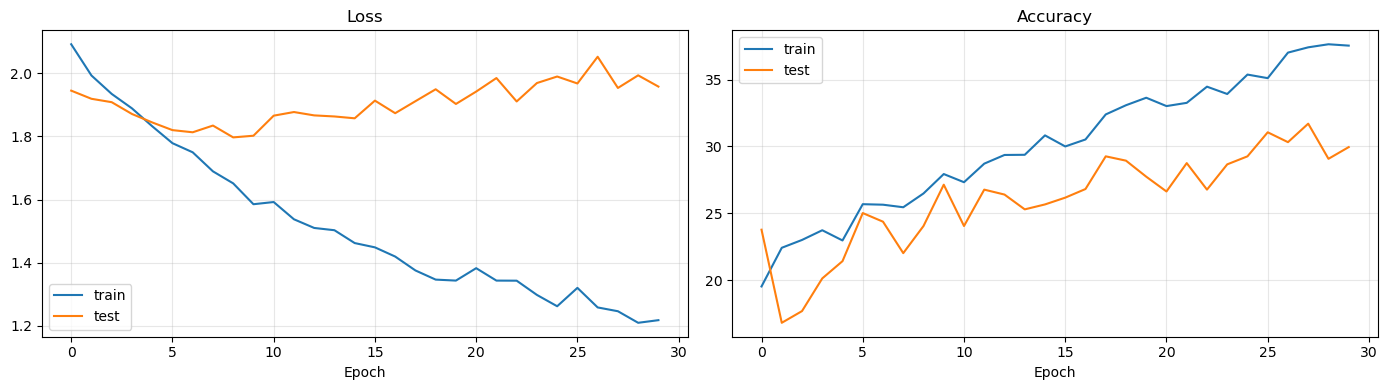

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["test_loss"], label="test")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["test_acc"], label="test")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Test accuracy: 29.95%
Test loss: 1.9583

              precision    recall  f1-score   support

       angry       0.23      0.70      0.35       197
     excited       0.36      0.30      0.33       459
        fear       0.08      0.27      0.12        30
  frustrated       0.41      0.13      0.20       611
       happy       0.15      0.18      0.16       154
     neutral       0.33      0.21      0.26       386
         sad       0.45      0.55      0.50       311
    surprise       0.06      0.32      0.11        19

    accuracy                           0.30      2167
   macro avg       0.26      0.33      0.25      2167
weighted avg       0.35      0.30      0.29      2167



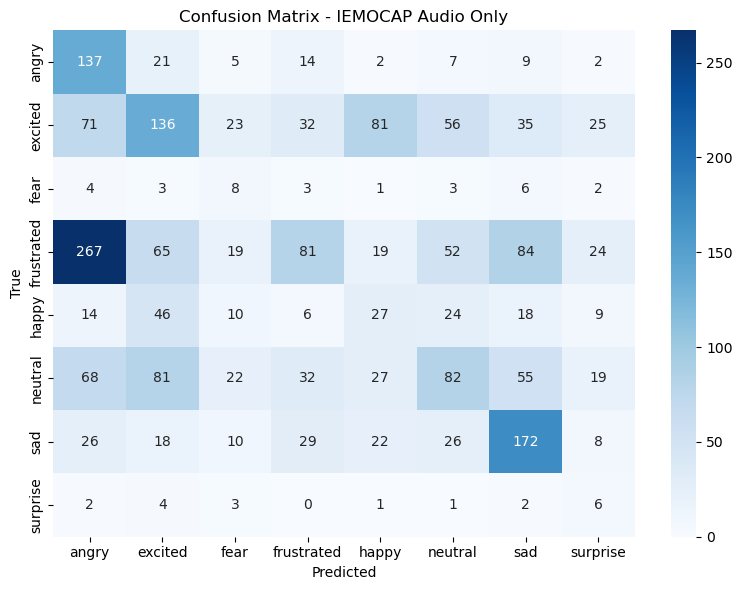

In [15]:
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
test_loss, test_acc, all_preds, all_labels = evaluate_model(model, test_loader, criterion, device)

print(f"Test accuracy: {test_acc:.2f}%")
print(f"Test loss: {test_loss:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=label_names, zero_division=0))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)
plt.title("Confusion Matrix - IEMOCAP Audio Only")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## Save Checkpoint

In [16]:
os.makedirs(os.path.dirname(CHECKPOINT_PATH), exist_ok=True)
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "label_names": label_names,
        "label_to_idx": label_to_idx,
        "idx_to_label": idx_to_label,
        "scaler_mean": scaler.mean_,
        "scaler_scale": scaler.scale_,
        "config": {
            "dataset_id": DATASET_ID,
            "label_column": LABEL_COLUMN,
            "drop_labels": sorted(DROP_LABELS),
            "min_samples_per_class": MIN_SAMPLES_PER_CLASS,
            "test_sessions": list(TEST_SESSIONS),
            "wave2vec_model_name": WAVE2VEC_MODEL_NAME,
        },
        "history": history,
    },
    CHECKPOINT_PATH,
)
print(f"Saved checkpoint to: {CHECKPOINT_PATH}")

Saved checkpoint to: models/IEMOCAP_audio_only.pth
